### Imports

In [8]:
import pandas as pd 
import numpy as np 



In [178]:
import os
import pickle as pkl

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data

### Reading in the Data

In [183]:
df_2 = pd.read_csv("et_raw_read_counts.csv")

In [71]:
# df_2.index= df_2['gene']

In [72]:
# df_2 = df_2.drop(columns=['gene'])

In [184]:
df_2.set_index(['gene'],inplace=True)

In [185]:
df_2.drop(['C5', 'D12'],axis=1, inplace=True)

In [186]:
df_2

,B7,B8,B9,B10,B11,C1,C2,C3,C4,D1,...,C9,C10,C11,C12,D2,D6,D7,D8,D9,D10
gene,,,,,,,,,,,,,,,,,,,,,
MTVR2,0,0,0,1,0,1,2,1,0,4,...,1,0,0,2,0,1,0,0,1,0
ATRX,2258,2664,3477,2936,2925,2374,2342,3432,2836,3068,...,4240,2950,2709,2131,3641,2730,2196,2244,2557,2505
LOC441204,73,81,85,87,69,52,37,69,96,76,...,135,85,50,26,137,62,59,89,26,35
TCOF1,234,277,341,285,333,278,266,263,299,252,...,361,270,219,220,301,298,233,213,344,276
NSRP1,248,392,540,380,350,307,300,399,363,317,...,491,331,320,267,447,363,286,301,372,329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GNGT1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SELT,109,242,239,236,150,65,93,197,145,151,...,193,176,94,122,237,146,144,187,105,80
SELV,0,0,1,0,0,1,0,1,0,1,...,0,0,0,4,0,1,0,1,1,1


In [188]:
genes_to_keep = df_2.columns[df_2.sum(axis=0) >= 10]
counts_df = df_2[genes_to_keep]

In [189]:
counts_df_filtered = counts_df.drop(['C5','D12'],axis=1)

KeyError: "['C5', 'D12'] not found in axis"

In [190]:
counts_df_filtered

,B7,B8,B9,B10,B11,C1,C2,C3,C4,D1,...,C9,C10,C11,C12,D2,D6,D7,D8,D9,D10
gene,,,,,,,,,,,,,,,,,,,,,
MTVR2,0,0,0,1,0,1,2,1,0,4,...,1,0,0,2,0,1,0,0,1,0
ATRX,2258,2664,3477,2936,2925,2374,2342,3432,2836,3068,...,4240,2950,2709,2131,3641,2730,2196,2244,2557,2505
LOC441204,73,81,85,87,69,52,37,69,96,76,...,135,85,50,26,137,62,59,89,26,35
TCOF1,234,277,341,285,333,278,266,263,299,252,...,361,270,219,220,301,298,233,213,344,276
NSRP1,248,392,540,380,350,307,300,399,363,317,...,491,331,320,267,447,363,286,301,372,329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GNGT1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SELT,109,242,239,236,150,65,93,197,145,151,...,193,176,94,122,237,146,144,187,105,80
SELV,0,0,1,0,0,1,0,1,0,1,...,0,0,0,4,0,1,0,1,1,1


In [191]:
# found patient ID and disease on NCBI GEO
# skipping C5, D12 becuase it was labeled an outlier on paper
et_patient_ids = ['A1','A2','A3','A4','A5',
                  'A6','A7','A8','A9','A10',
                  'A11','A12','B1','B2','B3','B4',
                  'B5','B6','B12','C6','C7','C8',
                  'C9','C10','C11','C12','D2','D6',
                  'D7', 'D8','D9','D10']

control_patient_ids = ['B7','B8','B9','B10','B11',
                       'C1','C2','C3','C4','D1','D3',
                       'D4','D5','E1','E2','E3','E4',
                       'E5','E6','E7']

In [192]:
df = pd.DataFrame({
    'patient_id': control_patient_ids + et_patient_ids,
    'condition' : ['control'] * len(control_patient_ids) + ['ET'] * len(et_patient_ids)
})

df = df.set_index('patient_id')

In [193]:
df_2 = df_2[~df_2.index.duplicated(keep='first')]
df_2

,B7,B8,B9,B10,B11,C1,C2,C3,C4,D1,...,C9,C10,C11,C12,D2,D6,D7,D8,D9,D10
gene,,,,,,,,,,,,,,,,,,,,,
MTVR2,0,0,0,1,0,1,2,1,0,4,...,1,0,0,2,0,1,0,0,1,0
ATRX,2258,2664,3477,2936,2925,2374,2342,3432,2836,3068,...,4240,2950,2709,2131,3641,2730,2196,2244,2557,2505
LOC441204,73,81,85,87,69,52,37,69,96,76,...,135,85,50,26,137,62,59,89,26,35
TCOF1,234,277,341,285,333,278,266,263,299,252,...,361,270,219,220,301,298,233,213,344,276
NSRP1,248,392,540,380,350,307,300,399,363,317,...,491,331,320,267,447,363,286,301,372,329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GNGT1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SELT,109,242,239,236,150,65,93,197,145,151,...,193,176,94,122,237,146,144,187,105,80
SELV,0,0,1,0,0,1,0,1,0,1,...,0,0,0,4,0,1,0,1,1,1


In [194]:
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=df_2.transpose(),
    metadata=df,
    refit_cooks=True,
    inference=inference,
    # n_cpus=8, # n_cpus can be specified here or in the inference object
)

In [195]:
# Check for duplicate gene names (columns)
dds

AnnData object with n_obs × n_vars = 52 × 23800
    obs: 'condition'
    obsm: 'design_matrix'

In [196]:
dds.deseq2()

Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 1.55 seconds.

Fitting dispersion trend curve...
... done in 0.30 seconds.

Fitting MAP dispersions...
... done in 2.07 seconds.

Fitting LFCs...
... done in 1.10 seconds.

Calculating cook's distance...
... done in 0.05 seconds.

Replacing 26 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.



In [197]:
ds = DeseqStats(dds, contrast=["condition", "control", "ET"], inference=inference)


In [198]:
ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: condition control vs ET
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene                                                                          
MTVR2         0.667385        0.308396  0.591213  0.521633  0.601926  0.999601
ATRX       2579.888786       -0.057264  0.042330 -1.352805  0.176118  0.828751
LOC441204    64.640850        0.164854  0.148644  1.109054  0.267407  0.901247
TCOF1       258.595758       -0.038008  0.051422 -0.739144  0.459819  0.995291
NSRP1       315.884651       -0.019520  0.047786 -0.408476  0.682924  0.999601
...                ...             ...       ...       ...       ...       ...
GNGT1         0.039989        0.003176  3.106097  0.001022  0.999184  0.999601
SELT        148.899533       -0.051259  0.102253 -0.501299  0.616161  0.999601
SELV          0.658505       -0.242119  0.635368 -0.381069  0.703152  0.999601
NFIX       1701.577177        0.032040  0.050127  0.639176  0.522708 

... done in 0.74 seconds.



Running Wald tests...
... done in 0.91 seconds.



Log2 fold change & Wald test p-value: condition control vs ET
              baseMean  log2FoldChange     lfcSE      stat    pvalue  padj
gene                                                                      
MTVR2         0.667385        0.308396  0.591213  0.352489  0.724471   1.0
ATRX       2579.888786       -0.057264  0.042330  0.000000  1.000000   1.0
LOC441204    64.640850        0.164854  0.148644  0.436305  0.662615   1.0
TCOF1       258.595758       -0.038008  0.051422  0.000000  1.000000   1.0
NSRP1       315.884651       -0.019520  0.047786  0.000000  1.000000   1.0
...                ...             ...       ...       ...       ...   ...
GNGT1         0.039989        0.003176  3.106097  0.000000  1.000000   1.0
SELT        148.899533       -0.051259  0.102253  0.000000  1.000000   1.0
SELV          0.658505       -0.242119  0.635368 -0.223680  0.823006   1.0
NFIX       1701.577177        0.032040  0.050127  0.000000  1.000000   1.0
SELP          0.907592        0.874715

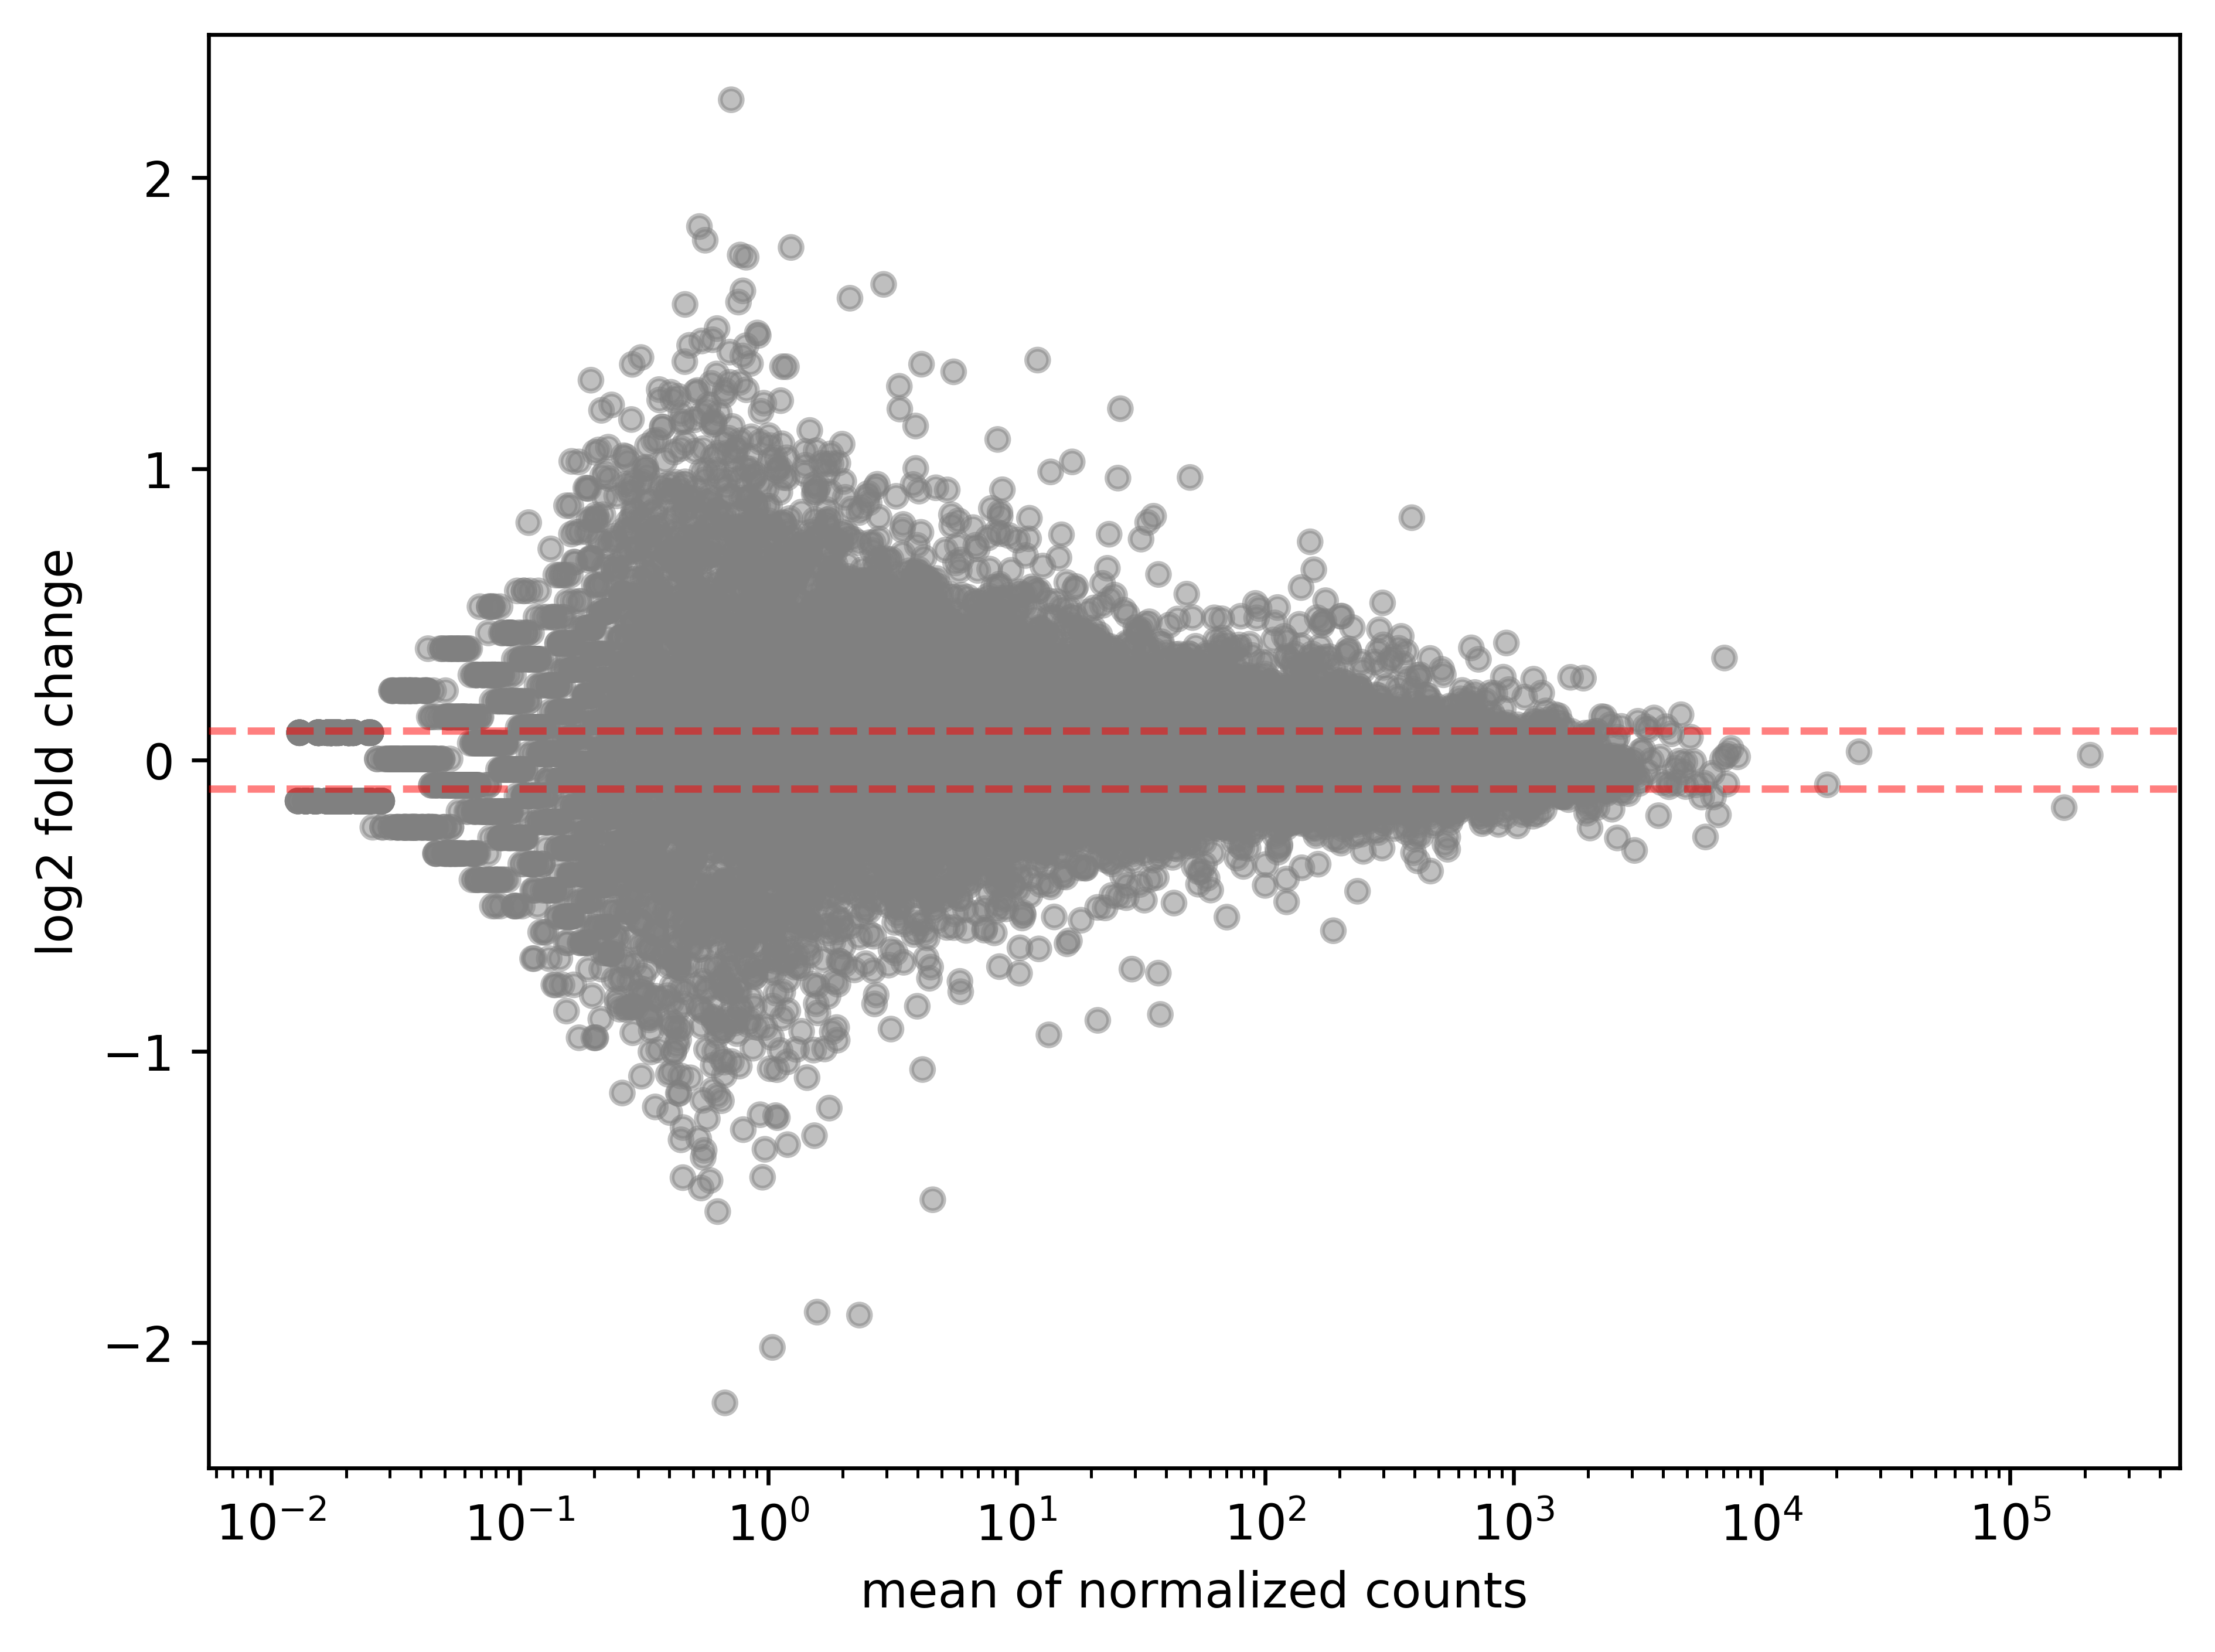

In [199]:
ds.summary(lfc_null=0.1, alt_hypothesis="greaterAbs")
# uses a statistical model to compare conditions with log2(a/b) 
ds.plot_MA(s=20)

In [168]:
ds_results_df = ds.results_df

In [177]:
res_sorted = ds_results_df.sort_values(by="log2FoldChange",ascending=False)
res_sorted

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene,,,,,,
DKFZP434L187,0.710501,2.266529,1.015692,2.133056,0.032920,1.0
TAS2R41,0.529014,1.831125,0.805247,2.149807,0.031571,1.0
IDH1-AS1,0.558381,1.784173,0.634503,2.654320,0.007947,1.0
TOP2A,1.237171,1.759311,0.732561,2.265082,0.023508,1.0
LRRC2-AS1,0.771910,1.733332,0.555866,2.938356,0.003300,1.0
...,...,...,...,...,...,...
MT4,0.000000,NaN,NaN,NaN,NaN,NaN
HPVC1,0.000000,NaN,NaN,NaN,NaN,NaN
TRIM51HP,0.000000,NaN,NaN,NaN,NaN,NaN


In [81]:
df_2_et_patients = df_2[et_patient_ids]
df_2_control_patients = df_2[control_patient_ids]

In [82]:
df_2_control_patients

,B7,B8,B9,B10,B11,C1,C2,C3,C4,D1,D3,D4,D5,E1,E2,E3,E4,E5,E6,E7
gene,,,,,,,,,,,,,,,,,,,,
MTVR2,0,0,0,1,0,1,2,1,0,4,0,1,0,1,1,0,2,0,1,0
ATRX,2258,2664,3477,2936,2925,2374,2342,3432,2836,3068,2469,3042,2804,2383,1979,2229,2364,1906,2487,2163
LOC441204,73,81,85,87,69,52,37,69,96,76,77,19,65,25,119,131,45,58,84,90
TCOF1,234,277,341,285,333,278,266,263,299,252,272,260,284,256,213,243,198,181,260,279
NSRP1,248,392,540,380,350,307,300,399,363,317,352,244,357,344,303,323,224,204,342,277
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GNGT1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
SELT,109,242,239,236,150,65,93,197,145,151,102,119,105,215,135,155,90,105,156,293
SELV,0,0,1,0,0,1,0,1,0,1,0,2,0,0,0,1,0,1,2,2


In [9]:
df = pd.read_csv('Essential_Tremor_Raw_RNA_counts.tsv', sep='\t', index_col=0)

In [6]:
conversion = pd.read_csv("id_to_gene.tsv", sep='\t', index_col=0)

/var/folders/gt/1c8d4lks1vgbghz7rr9vnqzm0000gn/T/ipykernel_88131/964778370.py:1: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  conversion = pd.read_csv("id_to_gene.tsv", sep='\t', index_col=0)


In [29]:
df.index = conversion['Symbol']

In [37]:
conversion['GeneType']

GeneID
100287102            pseudo
653635               pseudo
102466751             ncRNA
107985730             ncRNA
100302278             ncRNA
                  ...      
4541         protein-coding
4556                   tRNA
4519         protein-coding
4576                   tRNA
4571                   tRNA
Name: GeneType, Length: 39376, dtype: object

In [51]:
# Only looking to keep protein coding genes, as those are the ones that will generate the majority of the transcripts
conversion_protein_coding = conversion[conversion['GeneType'] == 'protein-coding']

In [54]:
conversion_protein_coding['Symbol']

GeneID
79501               OR4F5
112268260    LOC112268260
729759             OR4F29
105378947    LOC105378947
81399              OR4F16
                 ...     
4539                 ND4L
4538                  ND4
4540                  ND5
4541                  ND6
4519                 CYTB
Name: Symbol, Length: 19416, dtype: object

In [55]:
# .loc is used to filter a df based on its specific index values
df_protein_coding = df.loc[conversion_protein_coding['Symbol']]

In [58]:
df_protein_coding.columns

Index(['GSM3974827', 'GSM3974828', 'GSM3974829', 'GSM3974830', 'GSM3974831',
       'GSM3974832', 'GSM3974833', 'GSM3974834', 'GSM3974835', 'GSM3974836',
       'GSM3974837', 'GSM3974838', 'GSM3974839', 'GSM3974840', 'GSM3974841',
       'GSM3974842', 'GSM3974843', 'GSM3974844', 'GSM3974845', 'GSM3974846',
       'GSM3974847', 'GSM3974848', 'GSM3974849', 'GSM3974850', 'GSM3974851',
       'GSM3974852', 'GSM3974853', 'GSM3974854', 'GSM3974855', 'GSM3974856',
       'GSM3974857', 'GSM3974858', 'GSM3974859', 'GSM3974860', 'GSM3974861',
       'GSM3974862', 'GSM3974863', 'GSM3974864', 'GSM3974865', 'GSM3974866',
       'GSM3974867', 'GSM3974868', 'GSM3974869', 'GSM3974870', 'GSM3974871',
       'GSM3974872', 'GSM3974873', 'GSM3974874', 'GSM3974875', 'GSM3974876',
       'GSM3974877', 'GSM3974878', 'GSM3974879', 'GSM3974880', 'GeneID'],
      dtype='object')

In [63]:
df_protein_coding.loc[:,'ATRX']

KeyError: 'ATRX'

In [44]:
df[df.index==conversion[conversion['GeneType'] == 'protein-coding']]

ValueError: Unable to coerce to Series, length must be 17: given 39376

In [40]:
df

,GSM3974827,GSM3974828,GSM3974829,GSM3974830,GSM3974831,GSM3974832,GSM3974833,GSM3974834,GSM3974835,GSM3974836,...,GSM3974872,GSM3974873,GSM3974874,GSM3974875,GSM3974876,GSM3974877,GSM3974878,GSM3974879,GSM3974880,GeneID
Symbol,,,,,,,,,,,,,,,,,,,,,
DDX11L1,3,3,4,2,5,3,5,2,2,3,...,5,3,6,5,5,2,2,3,6,DDX11L1
WASH7P,79,38,61,48,54,56,65,47,32,40,...,51,52,67,50,49,37,49,52,67,WASH7P
MIR6859-1,3,2,2,2,3,5,1,1,1,2,...,4,3,5,4,2,0,4,4,3,MIR6859-1
MIR1302-2HG,1,0,1,0,0,0,0,0,0,1,...,0,0,1,0,1,1,0,0,0,MIR1302-2HG
MIR1302-2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,MIR1302-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ND6,9419,8387,6926,5414,5196,5607,10828,8103,7779,6318,...,8439,8687,12123,6192,8356,7823,4551,5474,10541,ND6
TRNE,1237,384,442,228,232,209,437,245,235,211,...,369,756,732,247,459,341,212,216,774,TRNE
CYTB,18912,15109,12299,12197,11551,10615,19189,15960,16447,10511,...,13190,16827,22876,9294,13591,13372,10943,12620,18944,CYTB


In [21]:
arr_gene_id = []
for i in conversion.index:
    arr_gene_id.append(i)


In [22]:
arr_symbol = []
for i in conversion['Symbol']:
    arr_symbol.append(i)

In [23]:
gene_id_to_symbol = dict(zip(arr_gene_id, arr_symbol))

In [31]:
arr_symbol

['DDX11L1',
 'WASH7P',
 'MIR6859-1',
 'MIR1302-2HG',
 'MIR1302-2',
 'FAM138A',
 'OR4F5',
 'LOC100996442',
 'LOC729737',
 'DDX11L17',
 'WASH9P',
 'MIR6859-2',
 'LOC107985721',
 'LOC112268260',
 'OR4F29',
 'LOC100132287',
 'LOC105378947',
 'LOC101928626',
 'MIR12136',
 'OR4F16',
 'LOC100133331',
 'LOC107984841',
 'LOC107984847',
 'LOC107984849',
 'LOC100288069',
 'LINC01409',
 'FAM87B',
 'LINC00115',
 'LINC01128',
 'LOC107984850',
 'FAM41C',
 'LOC284600',
 'LINC02593',
 'LOC107985728',
 'SAMD11',
 'NOC2L',
 'KLHL17',
 'PLEKHN1',
 'PERM1',
 'HES4',
 'ISG15',
 'AGRN',
 'LOC100288175',
 'LOC112267874',
 'LOC105378948',
 'RNF223',
 'C1orf159',
 'LINC01342',
 'MIR200B',
 'MIR200A',
 'MIR429',
 'TTLL10-AS1',
 'TTLL10',
 'TNFRSF18',
 'TNFRSF4',
 'SDF4',
 'B3GALT6',
 'C1QTNF12',
 'UBE2J2',
 'LINC01786',
 'SCNN1D',
 'ACAP3',
 'MIR6726',
 'SNORD167',
 'PUSL1',
 'INTS11',
 'MIR6727',
 'CPTP',
 'TAS1R3',
 'DVL1',
 'MIR6808',
 'MXRA8',
 'AURKAIP1',
 'CCNL2',
 'MRPL20-AS1',
 'MRPL20',
 'LOC107984868',

In [11]:
df.head() # probably just want protein coding genes

,GSM3974827,GSM3974828,GSM3974829,GSM3974830,GSM3974831,GSM3974832,GSM3974833,GSM3974834,GSM3974835,GSM3974836,...,GSM3974871,GSM3974872,GSM3974873,GSM3974874,GSM3974875,GSM3974876,GSM3974877,GSM3974878,GSM3974879,GSM3974880
GeneID,,,,,,,,,,,,,,,,,,,,,
100287102,3,3,4,2,5,3,5,2,2,3,...,6,5,3,6,5,5,2,2,3,6
653635,79,38,61,48,54,56,65,47,32,40,...,64,51,52,67,50,49,37,49,52,67
102466751,3,2,2,2,3,5,1,1,1,2,...,4,4,3,5,4,2,0,4,4,3
107985730,1,0,1,0,0,0,0,0,0,1,...,0,0,0,1,0,1,1,0,0,0
100302278,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
conversion

,Symbol,Description,Synonyms,GeneType,EnsemblGeneID,Status,ChrAcc,ChrStart,ChrStop,Orientation,Length,GOFunctionID,GOProcessID,GOComponentID,GOFunction,GOProcess,GOComponent
GeneID,,,,,,,,,,,,,,,,,
100287102,DDX11L1,DEAD/H-box helicase 11 like 1 (pseudogene),NaN,pseudo,ENSG00000290825,active,NC_000001.11,11874,14409,positive,1652,NaN,NaN,NaN,NaN,NaN,NaN
653635,WASH7P,"WASP family homolog 7, pseudogene",FAM39F|WASH5P,pseudo,NaN,active,NC_000001.11,14362,29370,negative,1769,NaN,NaN,NaN,NaN,NaN,NaN
102466751,MIR6859-1,microRNA 6859-1,hsa-mir-6859-1,ncRNA,ENSG00000278267,active,NC_000001.11,17369,17436,negative,68,NaN,NaN,NaN,NaN,NaN,NaN
107985730,MIR1302-2HG,MIR1302-2 host gene,NaN,ncRNA,NaN,active,NC_000001.11,29926,31295,positive,538,NaN,NaN,NaN,NaN,NaN,NaN
100302278,MIR1302-2,microRNA 1302-2,MIRN1302-2|hsa-mir-1302-2,ncRNA,ENSG00000284332,active,NC_000001.11,30366,30503,positive,138,NaN,GO:0035195,NaN,NaN,miRNA-mediated gene silencing,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4541,ND6,NADH dehydrogenase subunit 6,MTND6,protein-coding,NaN,active,NC_012920.1,14149,14673,negative,525,GO:0008137,GO:0006120///GO:0009060///GO:0032981///GO:0035...,GO:0005739///GO:0005743///GO:0005747,NADH dehydrogenase (ubiquinone) activity,"mitochondrial electron transport, NADH to ubiq...",mitochondrion///mitochondrial inner membrane//...
4556,TRNE,tRNA-Glu,MTTE,tRNA,NaN,active,NC_012920.1,14674,14742,negative,69,NaN,NaN,NaN,NaN,NaN,NaN
4519,CYTB,cytochrome b,MTCYB,protein-coding,NaN,active,NC_012920.1,14747,15887,positive,1141,GO:0008121///GO:0046872,GO:0006122///GO:0045333///GO:1902600,GO:0005739///GO:0005743///GO:0005750///GO:0016020,ubiquinol-cytochrome-c reductase activity///me...,"mitochondrial electron transport, ubiquinol to...",mitochondrion///mitochondrial inner membrane//...


In [30]:
df

,GSM3974827,GSM3974828,GSM3974829,GSM3974830,GSM3974831,GSM3974832,GSM3974833,GSM3974834,GSM3974835,GSM3974836,...,GSM3974872,GSM3974873,GSM3974874,GSM3974875,GSM3974876,GSM3974877,GSM3974878,GSM3974879,GSM3974880,GeneID
Symbol,,,,,,,,,,,,,,,,,,,,,
DDX11L1,3,3,4,2,5,3,5,2,2,3,...,5,3,6,5,5,2,2,3,6,DDX11L1
WASH7P,79,38,61,48,54,56,65,47,32,40,...,51,52,67,50,49,37,49,52,67,WASH7P
MIR6859-1,3,2,2,2,3,5,1,1,1,2,...,4,3,5,4,2,0,4,4,3,MIR6859-1
MIR1302-2HG,1,0,1,0,0,0,0,0,0,1,...,0,0,1,0,1,1,0,0,0,MIR1302-2HG
MIR1302-2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,MIR1302-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ND6,9419,8387,6926,5414,5196,5607,10828,8103,7779,6318,...,8439,8687,12123,6192,8356,7823,4551,5474,10541,ND6
TRNE,1237,384,442,228,232,209,437,245,235,211,...,369,756,732,247,459,341,212,216,774,TRNE
CYTB,18912,15109,12299,12197,11551,10615,19189,15960,16447,10511,...,13190,16827,22876,9294,13591,13372,10943,12620,18944,CYTB
